In [ ]:
!pip install network matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3138 sha256=4b11437dfcbd8901b1a3be6ac635b4e55615775ea84928f594a6858e035f4b0c
  Stored in directory: /root/.cache/pip/wheels/e7/5a/7a/7f15bea66afb5505b9d10cc7bd8964cb77f0ce736df5b104c8
Successfully built network


In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

In [ ]:
def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous[target]
    return path

In [ ]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Garis tebal merah untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

Jarak terpendek dari A ke Z: 14
Jalur Lintasan: A -> B -> D -> E -> Z


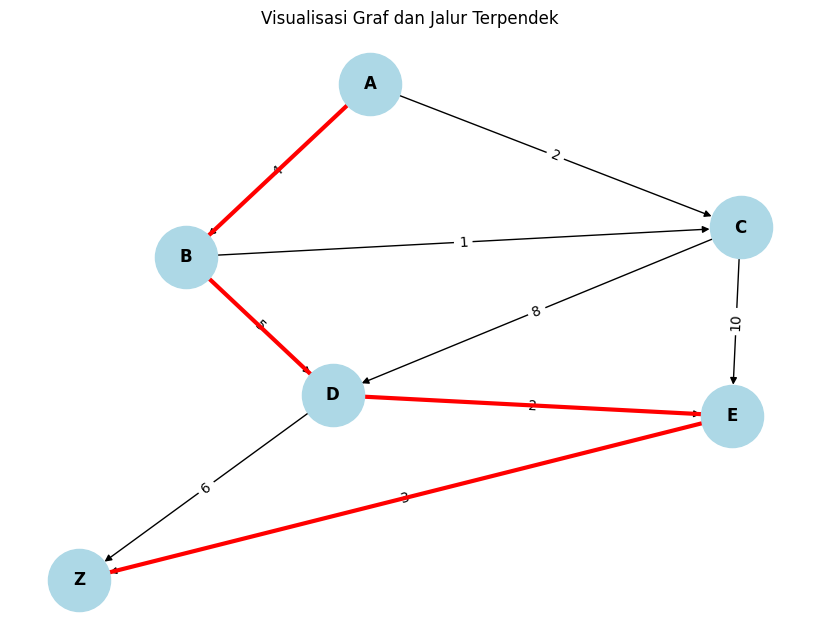

In [ ]:
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph, start_node)
shortest_path = get_path(previous, end_node)

print(f"Jarak terpendek dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur Lintasan: {' -> '.join(shortest_path)}")

visualize_graph(graph, path=shortest_path)

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


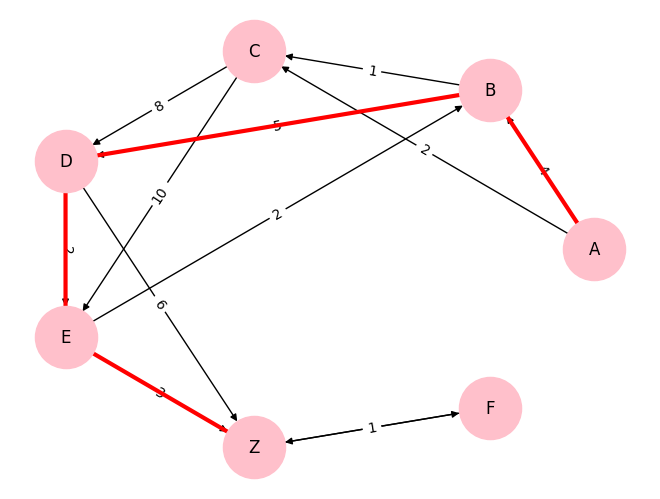

In [1]:
#TUGAS
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Fungsi Dijkstra
def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {}

    pq = [(0, start)]

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))

    return distances, previous

# Fungsi mencari jalur
def get_path(previous, end):
    path = [end]

    while end in previous:
        end = previous[end]
        path.append(end)

    path.reverse()
    return path

# Fungsi visualisasi
def visualize_graph(graph, path=[]):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Layout diganti circular_layout sesuai tugas
    pos = nx.circular_layout(G)

    nx.draw(G, pos, with_labels=True, node_color='pink',
            node_size=2000, font_size=12)

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    # Warnai jalur terpendek
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos,
                           edgelist=path_edges,
                           edge_color='red',
                           width=3)

    plt.show()

# Definisi graf
# Sudah dimodifikasi agar punya siklus
# dan ditambah simpul baru F

graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'B': 2},  # siklus E -> B
    'F': {'Z': 1},          # simpul baru
    'Z': {'F': 2}           # siklus Z -> F
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph, start_node)

shortest_path = get_path(previous, end_node)

print(f'Jarak dari {start_node} ke {end_node}: {distances[end_node]}')
print(f'Jalur: {" -> ".join(shortest_path)}')

# Visualisasi
visualize_graph(graph, path=shortest_path)